# detecting.expr1.fsize.fixed — Rh/Rl vs fsize (by timer)

**Data source**: `detecting.expr1.fsize.fixed` runs produced by [`TacVar/scripts/run_detecting_expr1_fsize_fixed10000_0416.sh`](../scripts/run_detecting_expr1_fsize_fixed10000_0416.sh).

This notebook scans all **fsize** combos under a single `TIMESTAMP` and computes **Rh/Rl** (TacVar v0.0 tile metrics) for each **timer × fsize**.

- **x-axis**: `fsize` (KiB)
- **legend**: timers
- **top y-axis**: `Rh`
- **bottom y-axis**: `Rl`

Metric definition:
- `U`: measured `ta` samples (`partes_ta_r*.csv`) for the (timer, fsize) combo (expects **single walk**: `NWALKS=1`).
- `V`: theory samples from `Normal(mu_ns, SIGMA_REL × mu_ns)`.
- `Rh/Rl`: `TacVar/utils/metrics_wasserstein.py:w_rl_rh_from_samples(U, V, ntiles=100, q=0.9, drop=0.995)`.

Adjust **cell 1** (`DATA_ROOT`, `HOSTNAME`, `TIMESTAMP`, optional combo filters).


In [5]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_repo_root(start: Path) -> Path:
    # Make imports work under both interactive Jupyter and nbconvert.
    for p in (start, *start.parents):
        if (p / "TacVar" / "utils" / "metrics_wasserstein.py").is_file():
            return p
    raise FileNotFoundError("Could not locate repo root containing TacVar/utils/metrics_wasserstein.py")


_REPO_ROOT = _find_repo_root(Path.cwd().resolve())
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from TacVar.utils.metrics_wasserstein import w_rl_rh_from_samples

# =========================
# Config
# =========================

DATA_ROOT = Path("/astrum/home/hpchzy/code/data")

# Pick a day/host/timestamp from your output tree.
DATETIME = "20260416"
HOSTNAME = "cgnr6760pn2"
EXPR_NAME = "detecting.expr1.fsize.fixed"
TIMESTAMP = "20260416_144717"

EXP_ROOT = Path(f"{DATA_ROOT}/{DATETIME}/output/{HOSTNAME}/{EXPR_NAME}/{TIMESTAMP}")
print("EXP_ROOT:", EXP_ROOT.resolve())

WALK_LIST_NAME = "walk_list_normal.csv"

# Optional combo filters (set to None to accept all)
INTERVAL_NS: int | None = 10000
FKERN: str | None = None
RKERN: str | None = None
RSIZE_KIB: int | None = None

# Theory: same convention as gen_walklist.py --dist normal (sigma_rel × mu)
SIGMA_REL = 0.015
N_THEORY = 50_000
SEED = 42

# Rh/Rl metric parameters (explicit defaults)
NTILES_METRIC = 100
Q_SPLIT = 0.9
DROP = 0.995
DENOM_POLICY = "inf"  # 'inf' or 'nan'

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

EXP_ROOT: /astrum/home/hpchzy/code/data/20260416/output/cgnr6760pn2/detecting.expr1.fsize.fixed/20260416_144717


In [6]:
def _parse_combo(combo_name: str) -> dict[str, str]:
    out: dict[str, str] = {}
    for part in combo_name.split("_"):
        if not part:
            continue
        for k in ("interval", "fkern", "rkern", "fsize", "rsize"):
            if part.startswith(k):
                out[k] = part[len(k) :]
                break
    return out


def combo_dir_matches(
    combo_name: str,
    *,
    interval_ns: int | None,
    fkern: str | None,
    rkern: str | None,
    rsize_kib: int | None,
) -> bool:
    info = _parse_combo(combo_name)
    if interval_ns is not None and int(info.get("interval", "-1")) != int(interval_ns):
        return False
    if fkern is not None and info.get("fkern") != str(fkern):
        return False
    if rkern is not None and info.get("rkern") != str(rkern):
        return False
    if rsize_kib is not None:
        parsed = info.get("rsize")
        if parsed is None:
            return int(rsize_kib) == 0
        if int(parsed) != int(rsize_kib):
            return False
    return True


def list_timers(exp_root: Path) -> list[str]:
    timers: list[str] = []
    for p in sorted(exp_root.iterdir()):
        if not p.is_dir() or p.name.startswith("."):
            continue
        if p.name == "_archive":
            continue
        # Timer directories contain combo dirs with <timer>_walks/
        for combo in p.iterdir():
            if not combo.is_dir():
                continue
            walks = combo / f"{p.name}_walks"
            if walks.is_dir():
                timers.append(p.name)
                break
    return timers


def load_experiment_meta(meta_dir: Path) -> dict[str, str]:
    out: dict[str, str] = {}
    p_txt = meta_dir / "meta.txt"
    if p_txt.is_file():
        for line in p_txt.read_text().splitlines():
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            k, _, v = line.partition("=")
            out[k.strip()] = v.strip()
    p_md = meta_dir / "meta.md"
    if p_md.is_file():
        for m in re.finditer(
            r"^\|\s*([^|\n]+?)\s*\|\s*`([^`]*)`\s*\|",
            p_md.read_text(),
            re.MULTILINE,
        ):
            k = m.group(1).strip()
            if not k or k in ("Key", "Parameter", "Item") or k.startswith("---"):
                continue
            out[k] = m.group(2).strip()
    return out


def read_walk_dataframe(exp_root: Path, combo_dir: Path) -> tuple[pd.DataFrame, Path]:
    p_root = exp_root / WALK_LIST_NAME
    if p_root.is_file():
        return pd.read_csv(p_root), p_root
    p_combo = combo_dir / WALK_LIST_NAME
    if p_combo.is_file():
        return pd.read_csv(p_combo), p_combo
    raise FileNotFoundError(f"No {WALK_LIST_NAME} under {exp_root} or {combo_dir}")


def assert_single_walk(walk_df: pd.DataFrame) -> None:
    n = len(walk_df.index)
    if n != 1:
        raise ValueError(
            f"Expected exactly 1 row in walk list (single-walk run), got {n}. "
            "Set NWALKS=1 in the detecting script or pick another timestamp."
        )


def resolve_mu_ns(combo_path: Path, walk_df: pd.DataFrame) -> float:
    info = _parse_combo(combo_path.name)
    if "interval" in info:
        return float(info["interval"])
    meta = load_experiment_meta(combo_path)
    for k in ("walk_mu_ns", "walk_fixed_ns", "interval_ns"):
        v = meta.get(k)
        if v is not None and str(v).strip() != "":
            return float(v)
    return float(walk_df["ta_ns"].iloc[0])


def single_walk_dir(timer: str, combo: Path) -> Path:
    root = combo / f"{timer}_walks"
    dirs = sorted(p for p in root.glob("w*") if p.is_dir())
    if len(dirs) != 1:
        raise ValueError(
            f"Expected exactly 1 walk directory under {root}, found {len(dirs)}. "
            "Does this run use NWALKS=1?"
        )
    return dirs[0]


def load_ta_samples(walk_dirs: list[Path]) -> np.ndarray:
    blocks: list[np.ndarray] = []
    for wd in walk_dirs:
        for f in sorted(wd.glob("partes_ta_r*.csv")):
            arr = np.loadtxt(f, dtype=np.int64)
            if arr.ndim == 0:
                arr = np.array([arr], dtype=np.int64)
            blocks.append(arr.ravel())
    if not blocks:
        return np.array([], dtype=np.int64)
    return np.concatenate(blocks, axis=0)


def collect_fsize_combos(
    exp_root: Path,
    ref_timer: str,
    *,
    interval_ns: int | None,
    fkern: str | None,
    rkern: str | None,
    rsize_kib: int | None,
) -> dict[int, str]:
    base = exp_root / ref_timer
    if not base.is_dir():
        raise FileNotFoundError(f"Missing timer dir: {base}")
    out: dict[int, str] = {}
    for combo in sorted(base.iterdir()):
        if not combo.is_dir():
            continue
        if not combo_dir_matches(
            combo.name,
            interval_ns=interval_ns,
            fkern=fkern,
            rkern=rkern,
            rsize_kib=rsize_kib,
        ):
            continue
        info = _parse_combo(combo.name)
        if "fsize" not in info:
            continue
        fsize_kib = int(info["fsize"])
        if fsize_kib in out and out[fsize_kib] != combo.name:
            raise ValueError(f"Duplicate fsize={fsize_kib}: {out[fsize_kib]} vs {combo.name}")
        out[fsize_kib] = combo.name
    return out


@dataclass(frozen=True)
class PointResult:
    timer: str
    fsize_kib: int
    mu_ns: float
    n_meas: int
    rl: float
    rh: float
    w: float


In [7]:
# =========================
# Load + compute Rh/Rl table
# =========================

exp_root = Path(EXP_ROOT).resolve()
if not exp_root.is_dir():
    raise FileNotFoundError(f"EXP_ROOT not found: {exp_root}")

timers = list_timers(exp_root)
if not timers:
    raise RuntimeError(f"No timer directories under {exp_root}")
print("timers:", timers)

ref_timer = timers[0]
fsize_to_combo = collect_fsize_combos(
    exp_root,
    ref_timer,
    interval_ns=INTERVAL_NS,
    fkern=FKERN,
    rkern=RKERN,
    rsize_kib=RSIZE_KIB,
)
if not fsize_to_combo:
    raise RuntimeError(f"No fsize combos found under {exp_root/ref_timer}")

fsizes = sorted(fsize_to_combo.keys())
print("fsizes_kib:", fsizes)

rows: list[PointResult] = []
for fsize_kib in fsizes:
    combo_name = fsize_to_combo[fsize_kib]
    for tm in timers:
        combo_dir = exp_root / tm / combo_name
        if not combo_dir.is_dir():
            print(f"[skip] missing combo for timer={tm}, fsize={fsize_kib}: {combo_dir}")
            continue

        walk_df, _walk_path = read_walk_dataframe(exp_root, combo_dir)
        assert_single_walk(walk_df)
        mu_ns = resolve_mu_ns(combo_dir, walk_df)
        sigma_abs = float(mu_ns) * float(SIGMA_REL)

        wd = single_walk_dir(tm, combo_dir)
        U = load_ta_samples([wd]).astype(np.float64)
        if U.size == 0:
            print(f"[skip] empty measured samples for timer={tm}, fsize={fsize_kib}: {wd}")
            continue

        # Deterministic per fsize (independent of iteration order)
        rng = np.random.default_rng(int(SEED) + int(fsize_kib) * 1000)
        V = rng.normal(float(mu_ns), float(sigma_abs), size=int(N_THEORY)).astype(np.float64)

        res = w_rl_rh_from_samples(
            U,
            V,
            ntiles=int(NTILES_METRIC),
            q=float(Q_SPLIT),
            drop=float(DROP),
            denom_policy=str(DENOM_POLICY),
        )
        rows.append(
            PointResult(
                timer=tm,
                fsize_kib=int(fsize_kib),
                mu_ns=float(mu_ns),
                n_meas=int(U.size),
                rl=float(res["rl"]),
                rh=float(res["rh"]),
                w=float(res["w"]),
            )
        )

df = pd.DataFrame([r.__dict__ for r in rows])
if df.empty:
    raise RuntimeError("No data points computed (all combos missing/empty?)")

df = df.sort_values(["timer", "fsize_kib"]).reset_index(drop=True)
display(df.head(20))
print("n_rows:", len(df.index))

timers: ['clock_gettime', 'likwid', 'mpi_wtime', 'papi', 'papix6', 'tsc_asym']
fsizes_kib: [32, 64, 128, 256, 512, 1024, 2048, 4096]


,timer,fsize_kib,mu_ns,n_meas,rl,rh,w
0,clock_gettime,32,10000.0,6400,3.563775,3.364927,113.646010
1,clock_gettime,64,10000.0,6400,4.572863,3.621190,113.416495
2,clock_gettime,128,10000.0,6400,3.153193,1.014662,291.361740
3,clock_gettime,256,10000.0,6400,2.795077,1.127268,160.664870
4,clock_gettime,512,10000.0,6400,3.318849,1.021404,216.674476
5,clock_gettime,1024,10000.0,6400,3.089781,1.064977,207.829750
6,clock_gettime,2048,10000.0,6400,2.405331,0.778472,106.577419
7,clock_gettime,4096,10000.0,6400,2.427080,0.778825,136.315301
8,likwid,32,10000.0,6400,3.507597,1.143625,157.304236
9,likwid,64,10000.0,6400,3.154491,1.147186,161.197260


n_rows: 48


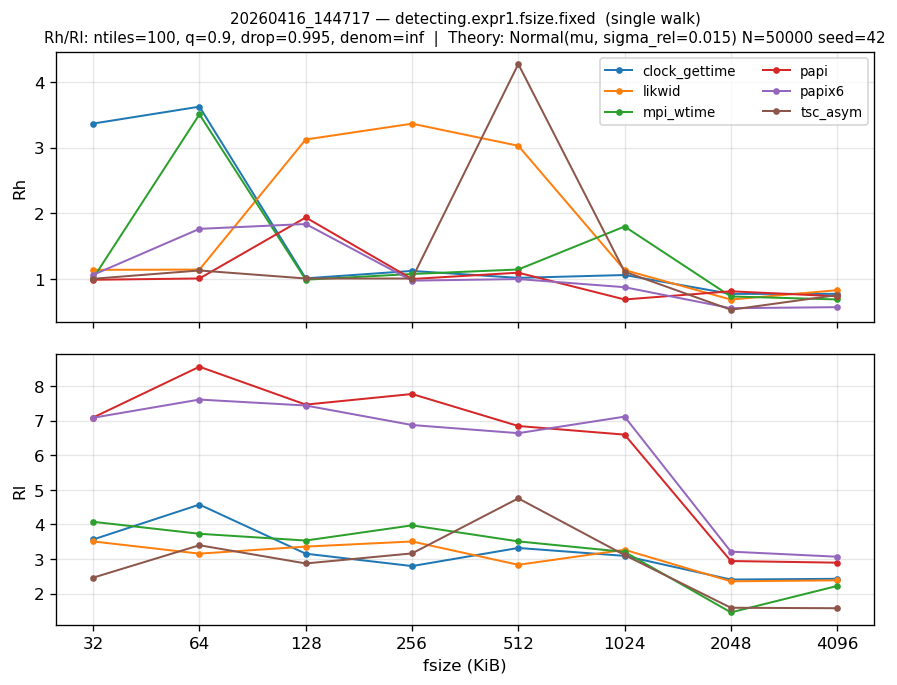

In [8]:
# =========================
# Plot: Rh (top) / Rl (bottom) vs fsize, legend by timer
# =========================

timers_present = sorted(df["timer"].unique().tolist())

# Use equal-spaced categorical x positions; show fsize as tick labels.
fsizes_all = sorted(df["fsize_kib"].unique().tolist())
xpos = np.arange(len(fsizes_all), dtype=float)
fsize_to_pos = {int(f): float(i) for i, f in enumerate(fsizes_all)}

fig, (ax_rh, ax_rl) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(8.8, 6.2),
    gridspec_kw={"hspace": 0.12},
)

for tm in timers_present:
    d = df[df["timer"] == tm].sort_values("fsize_kib")
    x = np.array([fsize_to_pos[int(v)] for v in d["fsize_kib"].to_numpy()], dtype=float)
    ax_rh.plot(x, d["rh"].to_numpy(dtype=float), marker="o", markersize=3, linewidth=1.2, label=tm)
    ax_rl.plot(x, d["rl"].to_numpy(dtype=float), marker="o", markersize=3, linewidth=1.2, label=tm)

ax_rh.set_ylabel("Rh")
ax_rl.set_ylabel("Rl")
ax_rl.set_xlabel("fsize (KiB)")
ax_rl.set_xticks(xpos)
ax_rl.set_xticklabels([str(int(f)) for f in fsizes_all])

ax_rh.grid(True, alpha=0.3)
ax_rl.grid(True, alpha=0.3)

title = (
    f"{exp_root.name} — {EXPR_NAME}  (single walk)\n"
    f"Rh/Rl: ntiles={NTILES_METRIC}, q={Q_SPLIT}, drop={DROP}, denom={DENOM_POLICY}  |  "
    f"Theory: Normal(mu, sigma_rel={SIGMA_REL}) N={N_THEORY} seed={SEED}"
)
ax_rh.set_title(title, fontsize=9)
ax_rh.legend(loc="best", fontsize=8, ncols=2)

plt.show()